In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install --upgrade plotly

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.8 MB 18.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.8 MB 16.5 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 14.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   --------------------------------

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
import plotly.io as pio
pio.renderers.default = "iframe"

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date, infer_datetime_format=True), y=stock_data_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date, infer_datetime_format=True), y=revenue_data_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock,
    xaxis_rangeslider_visible=True)
    fig.show()
    from IPython.display import display, HTML
    fig_html = fig.to_html()
    display(HTML(fig_html))

In [7]:
import yfinance as yf

tesla = yf.Ticker("TSLA")

tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)

print(tesla_data.head())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  


In [9]:
pip install lxml

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------  3.9/4.0 MB 26.7 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 22.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
response = requests.get(url)
html_data = response.text

soup = BeautifulSoup(html_data, "html.parser")

tables = pd.read_html(html_data)

for i, table in enumerate(tables):
    print(f"Tabla {i} columnas: {table.columns}")

tesla_revenue = tables[1] 

tesla_revenue.columns = ['Date', 'Revenue']

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(r',|\$', "", regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

print(tesla_revenue.tail())

Tabla 0 columnas: Index(['Tesla Annual Revenue (Millions of US $)', 'Tesla Annual Revenue (Millions of US $).1'], dtype='object')
Tabla 1 columnas: Index(['Tesla Quarterly Revenue (Millions of US $)', 'Tesla Quarterly Revenue (Millions of US $).1'], dtype='object')
Tabla 2 columnas: Index(['Sector', 'Industry', 'Market Cap', 'Revenue'], dtype='object')
Tabla 3 columnas: Index(['Stock Name', 'Country', 'Market Cap', 'PE Ratio'], dtype='object')
Tabla 4 columnas: Index(['Link Preview', 'HTML Code (Click to Copy)'], dtype='object')
Tabla 5 columnas: Index(['Link Preview', 'HTML Code (Click to Copy)'], dtype='object')
          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


In [12]:
import yfinance as yf

gme = yf.Ticker("GME")

gme_data = gme.history(period="max")

gme_data.reset_index(inplace=True)

print(gme_data.head())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620128  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658001  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578048  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662209  1.603295  1.662209   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [13]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
response = requests.get(url)
html_data_2 = response.text

soup = BeautifulSoup(html_data_2, "html.parser")

tables = pd.read_html(html_data_2)

for i, table in enumerate(tables):
    print(f"Tabla {i} columnas: {table.columns}")

gme_revenue = tables[1] 

gme_revenue.columns = ['Date', 'Revenue']

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r',|\$', "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

print(gme_revenue.tail())

Tabla 0 columnas: Index(['GameStop Annual Revenue (Millions of US $)', 'GameStop Annual Revenue (Millions of US $).1'], dtype='object')
Tabla 1 columnas: Index(['GameStop Quarterly Revenue (Millions of US $)', 'GameStop Quarterly Revenue (Millions of US $).1'], dtype='object')
Tabla 2 columnas: Index(['Sector', 'Industry', 'Market Cap', 'Revenue'], dtype='object')
Tabla 3 columnas: Index(['Stock Name', 'Country', 'Market Cap', 'PE Ratio'], dtype='object')
Tabla 4 columnas: Index(['Link Preview', 'HTML Code (Click to Copy)'], dtype='object')
Tabla 5 columnas: Index(['Link Preview', 'HTML Code (Click to Copy)'], dtype='object')
          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


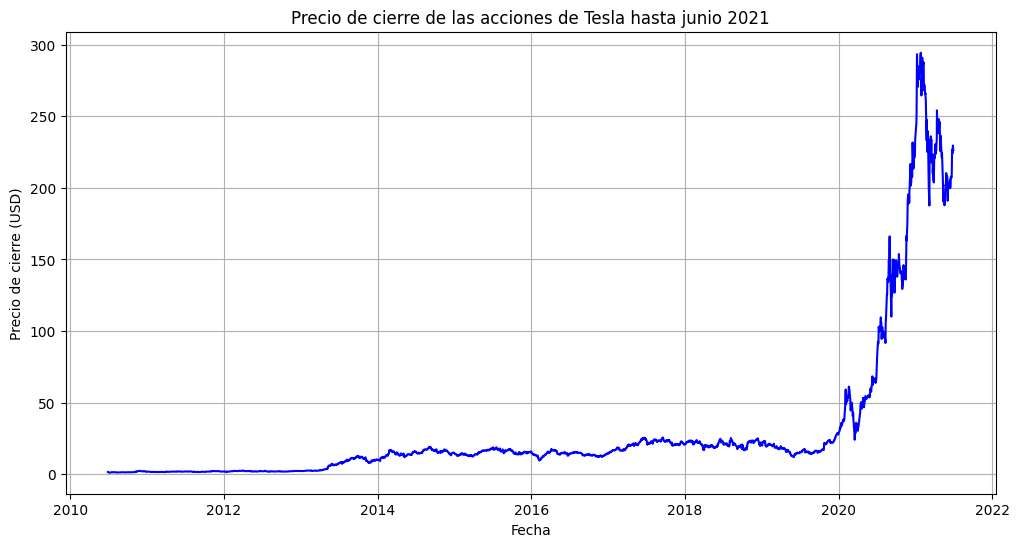

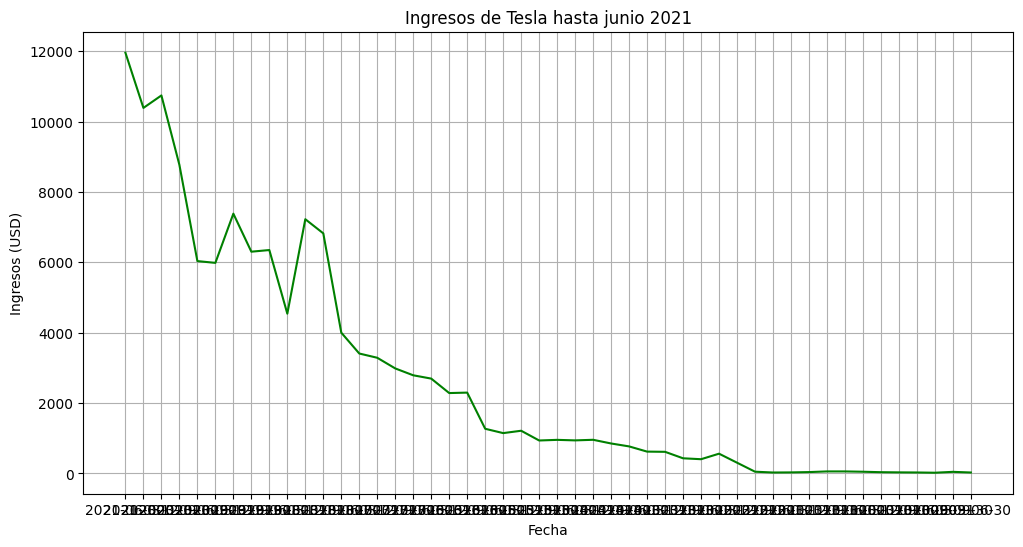

In [18]:
import matplotlib.pyplot as plt

tesla_data_filtered = tesla_data[tesla_data['Date'] <= '2021-06-30']
tesla_revenue_filtered = tesla_revenue[tesla_revenue['Date'] <= '2021-06-30']

plt.figure(figsize=(12, 6))
plt.plot(tesla_data_filtered['Date'], tesla_data_filtered['Close'], color='blue')
plt.title('Precio de cierre de las acciones de Tesla hasta junio 2021')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre (USD)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(tesla_revenue_filtered['Date'], tesla_revenue_filtered['Revenue'].astype(float), color='green')
plt.title('Ingresos de Tesla hasta junio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ingresos (USD)')
plt.grid(True)
plt.show()


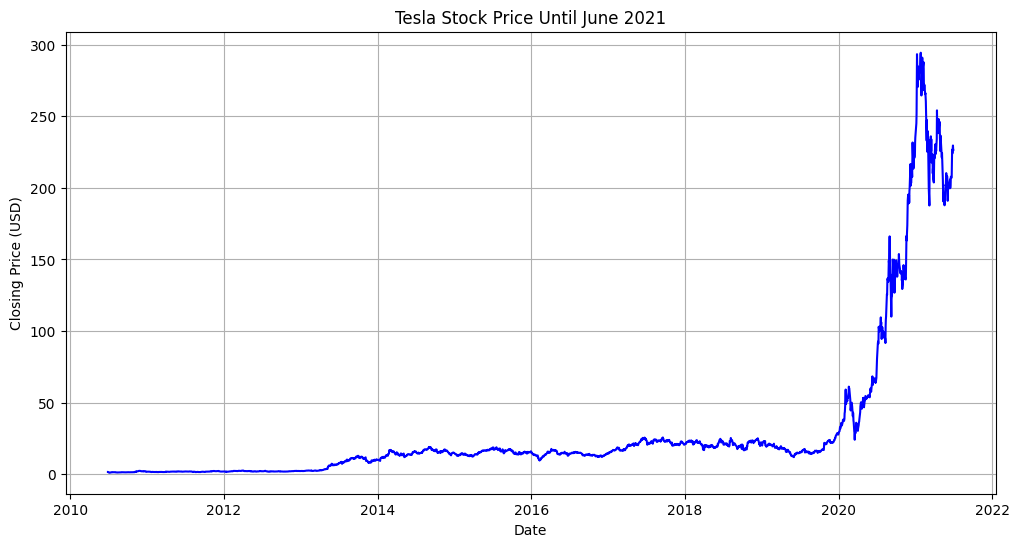

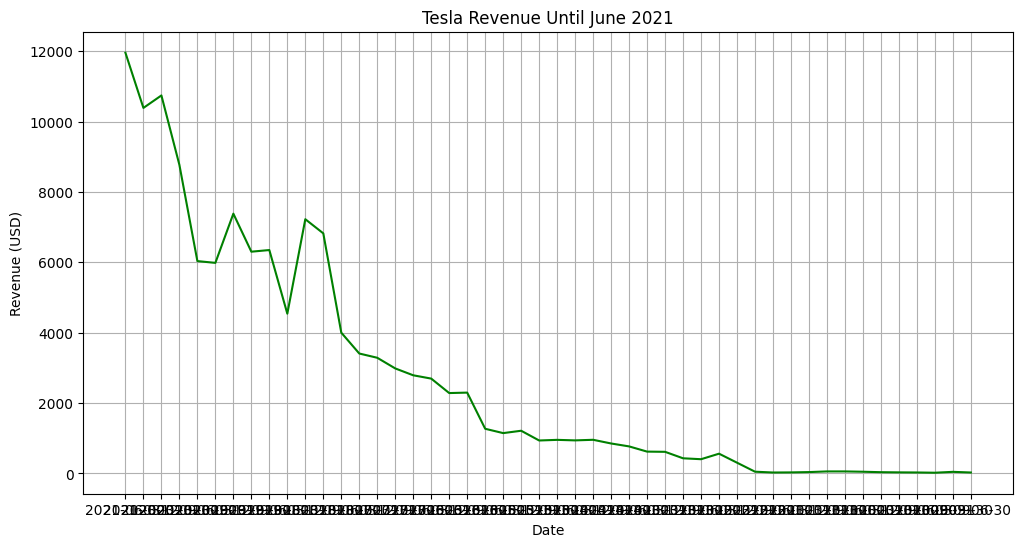

In [20]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock_name):
    # Filtrar datos hasta junio de 2021
    stock_data_filtered = stock_data[stock_data['Date'] <= '2021-06-30']
    revenue_data_filtered = revenue_data[revenue_data['Date'] <= '2021-06-30']

    # Gráfico 1: Precio de cierre de las acciones
    plt.figure(figsize=(12, 6))
    plt.plot(stock_data_filtered['Date'], stock_data_filtered['Close'], color='blue')
    plt.title(f'{stock_name} Stock Price Until June 2021')
    plt.xlabel('Date')
    plt.ylabel('Closing Price (USD)')
    plt.grid(True)
    plt.show()

    # Gráfico 2: Ingresos
    plt.figure(figsize=(12, 6))
    plt.plot(revenue_data_filtered['Date'], revenue_data_filtered['Revenue'].astype(float), color='green')
    plt.title(f'{stock_name} Revenue Until June 2021')
    plt.xlabel('Date')
    plt.ylabel('Revenue (USD)')
    plt.grid(True)
    plt.show()

# Llamada correcta a la función
make_graph(tesla_data, tesla_revenue, 'Tesla')